In [18]:
import sys, os
ROOT = os.path.abspath(os.curdir)
sys.path.append(os.path.abspath(os.path.join(ROOT,'src')))

# SET VALUES TO MATCH EXPERIMENT
LOAD_DIR = os.path.join(ROOT,'results')

import irl_maxent.gridworld as W
import irl_maxent.plot as P
import irl_maxent.solver as S

import mix_irl.irleed as I
import mix_irl.helpers as H
import mix_irl.irl as IRL

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from itertools import product       

import pickle
from tqdm import trange

from matplotlib.patches import Rectangle

In [19]:
ORANGE = '#FF9132'
RED   = '#B02105'
PINK = '#E600BF'
TEAL = '#0598B0'
GREEN = '#008F00'
PURPLE = '#8A2BE2'
GRAY = '#969696'
FIG_WIDTH = 3
FIG_HEIGHT = 3.5
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "lines.linewidth": 2
})
# global style for plots
style = {                                   
    'border': {'color': 'black', 'linewidth': 0.5},
    # 'border': None
}

legend_key = ['Dem.',
              'IRL', 
              'IRLEED',
              ]
color_key = [GRAY,
             ORANGE, 
             GREEN,
            ]       

## Gridworld

In [20]:
# UTILITIES

def normalize(vec):
    a, b = float(np.min(vec)), float(np.max(vec))
    return (vec - a) / (b - a + 1e-12)

def load_cell(LOAD_DIR, beta, lam, eps_str, env_id=1):
    base = (
        f"{LOAD_DIR}/gridworld_simple/irleed/env_{env_id}/"
        f"demo_beta_{beta:.3f}/{eps_str}"
    )
    if eps_str == "noeps":
        result_path = f"{base}/baseline.p"
    else:
        result_path = f"{base}/lam_{lam:.3f}.p"

    options, data = pickle.load(open(result_path, "rb"))
    return options, data, result_path

def aggregate_cell(
    data,
    max_T=None,
    n_features=49,
    beta_max=1e6,
    drop_bad_beta_seeds=True,
    eps_max=1e6,
    drop_bad_eps_seeds=False,
    theta_max=300,
    drop_bad_theta_seeds=True,
    ratios=None
):
    if max_T is None:
        raise ValueError("Pass max_T explicitly, e.g. max_T=options['max_steps']")
    max_T = int(max_T)

    returns = np.zeros(3)
    feat_sum = np.zeros(n_features)
    theta_sum = np.zeros((2, n_features))
    count = 0

    visit_sum = np.zeros(n_features, dtype=np.float64)
    visit_count = 0

    eps_sum = None
    eps_hist_sum = None
    eps_hist_count = None

    betas_hist_sum = None
    betas_hist_count = None

    # NEW: theta history accumulators
    theta_hist_sum = None          # (max_T, F)
    theta_hist_count = None        # (max_T, F)

    K = None

    for dat in data:
        if dat is None:
            continue

        # ----- NEW: dataset-level visitation frequency (Figure 2 top-right) -----
        # mvf = dat.get("mix_visit_freq", None)   # (K,S)
        
        # if mvf is not None:
        #     mvf = np.array(mvf, dtype=np.float64)
        
        #     # infer K,S
        #     if mvf.ndim == 2 and mvf.shape[1] == n_features:
        #         K_here = mvf.shape[0]

        #         # if ratios is None:
        #         #     w = np.ones(K_here) / K_here
        #         # else:
        #         #     w = np.array(ratios, dtype=np.float64)
        #         #     w = w / (w.sum() + 1e-12)
        
        #         # get weights for pooling across components
        #         if ratios is None:
        #             # fallback: uniform mixture if ratios weren't saved
        #             w = np.ones(K_here, dtype=np.float64) / K_here
        #         else:
        #             w = np.array(ratios, dtype=np.float64).reshape(-1)
        #             if w.shape[0] != K_here:
        #                 # another fallback if mismatch
        #                 w = np.ones(K_here, dtype=np.float64) / K_here
        #             else:
        #                 w = w / (w.sum() + 1e-12)
        
        #         # pooled dataset visitation over states: (S,)
        #         visit_dataset = (w[:, None] * mvf).sum(axis=0)
        
        #         if np.all(np.isfinite(visit_dataset)):
        #             visit_sum += visit_dataset
        #             visit_count += 1
        
        # ----- normal aggregates -----
        returns[0] += dat["dem_rews"]
        rews = dat["log"]["rewards"]
        returns[1] += rews[0]
        returns[2] += rews[1] if len(rews) > 1 else rews[0]

        scales = np.array(dat["mix_e_features"]).max(axis=1)
        feat_sum += ((np.array(dat["mix_e_features"]).T / scales).T).mean(axis=0)

        theta_sum[0] += np.array(dat["log"]["theta"][0]).reshape(-1)
        theta_sum[1] += np.array(dat["log"]["theta"][-1]).reshape(-1)

        # ----- NEW: theta history -----
        th_hist = dat["log"].get("theta", None)
        if th_hist is not None and len(th_hist) > 0:
            th_arr = np.stack([np.array(th).reshape(-1) for th in th_hist], axis=0)  # (t,F)
            bad_th = (not np.all(np.isfinite(th_arr))) or (np.nanmax(np.abs(th_arr)) > theta_max)
            if drop_bad_theta_seeds and bad_th:
                pass
            else:
                t_seed = th_arr.shape[0]
                th_pad = np.full((max_T, n_features), np.nan, dtype=np.float64)
                tt = min(max_T, t_seed)
                th_pad[:tt] = th_arr[:tt]

                if theta_hist_sum is None:
                    theta_hist_sum = np.zeros((max_T, n_features), dtype=np.float64)
                    theta_hist_count = np.zeros((max_T, n_features), dtype=np.float64)

                mask = np.isfinite(th_pad)
                theta_hist_sum[mask] += th_pad[mask]
                theta_hist_count[mask] += 1.0

        # ----- eps final + eps history (your code) -----
        if "epsilons" in dat["log"] and dat["log"]["epsilons"] is not None and len(dat["log"]["epsilons"]) > 0:
            eps_list_final = dat["log"]["epsilons"][-1]
            eps_stack_final = np.stack([np.array(e).reshape(-1) for e in eps_list_final], axis=0)
            if eps_sum is None:
                K = eps_stack_final.shape[0]
                eps_sum = np.zeros((K, n_features))
            eps_sum += eps_stack_final

            eps_hist_list = dat["log"]["epsilons"]
            t_seed = len(eps_hist_list)
            K_seed = len(eps_hist_list[0])

            eps_hist = np.stack(
                [np.stack([np.array(e).reshape(-1) for e in eps_hist_list[t]], axis=0) for t in range(t_seed)],
                axis=0
            )

            bad_eps = (not np.all(np.isfinite(eps_hist))) or (np.nanmax(np.abs(eps_hist)) > eps_max)
            if drop_bad_eps_seeds and bad_eps:
                pass
            else:
                eps_pad = np.full((max_T, K_seed, n_features), np.nan, dtype=np.float64)
                tt = min(max_T, t_seed)
                eps_pad[:tt] = eps_hist[:tt]

                if eps_hist_sum is None:
                    eps_hist_sum = np.zeros((max_T, K_seed, n_features), dtype=np.float64)
                    eps_hist_count = np.zeros((max_T, K_seed, n_features), dtype=np.float64)

                mask = np.isfinite(eps_pad)
                eps_hist_sum[mask] += eps_pad[mask]
                eps_hist_count[mask] += 1.0

        # ----- beta history (your code) -----
        if "betas" in dat["log"] and dat["log"]["betas"] is not None and len(dat["log"]["betas"]) > 0:
            b_hist = np.stack(dat["log"]["betas"], axis=0)
            bad_beta = (not np.all(np.isfinite(b_hist))) or (np.nanmax(np.abs(b_hist)) > beta_max)
            if drop_bad_beta_seeds and bad_beta:
                pass
            else:
                K2 = b_hist.shape[1]
                b_pad = np.full((max_T, K2), np.nan, dtype=np.float64)
                tt = min(max_T, b_hist.shape[0])
                b_pad[:tt] = b_hist[:tt]

                if betas_hist_sum is None:
                    betas_hist_sum = np.zeros((max_T, K2), dtype=np.float64)
                    betas_hist_count = np.zeros((max_T, K2), dtype=np.float64)

                mask = np.isfinite(b_pad)
                betas_hist_sum[mask] += b_pad[mask]
                betas_hist_count[mask] += 1.0

        count += 1

    if count == 0:
        raise RuntimeError("No non-None seeds in this file.")

    returns_mean = returns / count
    theta_pair_mean = theta_sum / count
    feat_mean = feat_sum / count
    # visit_mean = (visit_sum / (visit_count + 1e-12)) if visit_count > 0 else None
    eps_final_mean = (eps_sum / count) if eps_sum is not None else None

    betas_hist_mean = None
    if betas_hist_sum is not None:
        betas_hist_mean = betas_hist_sum / (betas_hist_count + 1e-12)

    eps_hist_mean = None
    if eps_hist_sum is not None:
        eps_hist_mean = eps_hist_sum / (eps_hist_count + 1e-12)

    # NEW: theta_hist_mean
    theta_hist_mean = None
    if theta_hist_sum is not None:
        theta_hist_mean = theta_hist_sum / (theta_hist_count + 1e-12)  # (T,F)

    return returns_mean, theta_pair_mean, feat_mean, eps_final_mean, eps_hist_mean, betas_hist_mean, theta_hist_mean, count, K, max_T

# def aggregate_cell(data, max_T=None, n_features=49):
#     if max_T is None:
#         raise ValueError("Pass max_T explicitly, e.g. max_T=options['max_steps']")
#     max_T = int(max_T)

#     returns = np.zeros(3)
#     feat_sum = np.zeros(n_features)
#     theta_sum = np.zeros((2, n_features))
#     count = 0

#     eps_sum = None
#     betas_hist_sum = None
#     betas_hist_count = None
#     K = None

#     for dat in data:
#         if dat is None:
#             continue

#         returns[0] += dat["dem_rews"]
#         rews = dat["log"]["rewards"]
#         returns[1] += rews[0]
#         returns[2] += rews[1] if len(rews) > 1 else rews[0]

#         scales = np.array(dat["mix_e_features"]).max(axis=1)
#         feat_sum += ((np.array(dat["mix_e_features"]).T / scales).T).mean(axis=0)

#         theta_sum[0] += np.array(dat["log"]["theta"][0]).reshape(-1)
#         theta_sum[1] += np.array(dat["log"]["theta"][-1]).reshape(-1)

#         if "epsilons" in dat["log"]:
#             eps_list = dat["log"]["epsilons"][-1]
#             eps_stack = np.stack([np.array(e).reshape(-1) for e in eps_list], axis=0)
#             if eps_sum is None:
#                 K = eps_stack.shape[0]
#                 eps_sum = np.zeros((K, n_features))
#             eps_sum += eps_stack

#         if "betas" in dat["log"]:
#             b_hist = np.stack(dat["log"]["betas"], axis=0)  # (t,K)
#             K2 = b_hist.shape[1]

#             b_pad = np.full((max_T, K2), np.nan, dtype=np.float64)
#             t = min(max_T, b_hist.shape[0])
#             b_pad[:t] = b_hist[:t]

#             if betas_hist_sum is None:
#                 betas_hist_sum = np.zeros((max_T, K2), dtype=np.float64)
#                 betas_hist_count = np.zeros((max_T, K2), dtype=np.float64)

#             mask = np.isfinite(b_pad)
#             betas_hist_sum[mask] += b_pad[mask]
#             betas_hist_count[mask] += 1.0

#         count += 1

#     if count == 0:
#         raise RuntimeError("No non-None seeds in this file.")

#     returns_mean = returns / count
#     theta_pair_mean = theta_sum / count
#     feat_mean = feat_sum / count
#     eps_final_mean = (eps_sum / count) if eps_sum is not None else None

#     betas_hist_mean = None
#     if betas_hist_sum is not None:
#         betas_hist_mean = betas_hist_sum / (betas_hist_count + 1e-12)

#     # If you really want T, it's just max_T now because you pad to max_T.
#     T = max_T

#     return returns_mean, theta_pair_mean, feat_mean, eps_final_mean, betas_hist_mean, count, K, T

def get_first_valid_seed(data):
    for i, dat in enumerate(data):
        if dat is not None:
            return i, dat
    raise RuntimeError("No non-None seeds found.")

In [21]:
# PLOTTERS

def plot_heatmap_and_return(results_for_beta, lams, beta, eps_str, save_dir, fig_prefix="IRL_vs_IRLEED"):
    # results_for_beta: (len(lams), 3) where [dem, irl, irleed]
    dem_rew   = results_for_beta[:, 0]
    irl_rew   = results_for_beta[:, 1]
    irleed_rew= results_for_beta[:, 2]

    heatmap = (irleed_rew / (irl_rew + 1e-12)) * 100.0  # (len(lams),)

    fig = plt.figure(figsize=(3.2, 2.0))
    spec = fig.add_gridspec(ncols=2, nrows=1, width_ratios=[0.5, 0.5],
                            left=0.07, right=0.99, top=0.88, bottom=0.13)
    spec.update(wspace=0.3, hspace=0)
    ax_heat = fig.add_subplot(spec[0, 0])
    ax_rew  = fig.add_subplot(spec[0, 1])

    fig.suptitle(fr'IRLEED vs IRL | $\beta_{{demo}}$={beta:.3f} | {eps_str}')

    # heat "map": make it 2D for imshow: (1, len(lams))
    divider = make_axes_locatable(ax_heat)
    cax = divider.append_axes('bottom', size='5%', pad=0.05)
    p = ax_heat.imshow(heatmap[None, :], origin='lower', vmin=100, cmap='Greens', aspect='auto')
    cbar = fig.colorbar(p, cax=cax, orientation='horizontal')
    cbar.set_ticks([100, 150, 200])
    cbar.set_ticklabels(["$100\\%$", "$150\\%$", "$200\\%$"])
    cbar.ax.tick_params(size=0)

    ax_heat.set_ylabel(r'$\beta$ index', labelpad=2)  # not super meaningful now
    ax_heat.set_xlabel(r'$\lambda$ index', labelpad=3)
    cax.set_xlabel('relative performance', labelpad=0)
    ax_heat.set_xticks([]); ax_heat.set_yticks([])
    ax_heat.spines['left'].set_visible(False)
    ax_heat.spines['bottom'].set_visible(False)
    ax_heat.xaxis.set_label_position('top')

    # return lines across lambdas
    ax_rew.plot(np.arange(len(lams)), irl_rew, label='IRL')
    ax_rew.plot(np.arange(len(lams)), irleed_rew, label='IRLEED')
    ax_rew.legend()
    ax_rew.set_ylabel('episode return', labelpad=0)
    ax_rew.set_xlabel(r'$\lambda$ index')
    ax_rew.set_xticks([])
    ax_rew.tick_params(size=0)
    ax_rew.grid(axis='y')

    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def compute_eps_theta_energy_shares(dat, max_T=None, n_features=49, eps_max=1e6):
    """
    Returns per-iteration shares:
      share_eps[t]   = energy(eps) / (energy(theta) + energy(eps))
      share_theta[t] = energy(theta) / (energy(theta) + energy(eps))

    where energy(theta) is ||theta_centered||^2
          energy(eps)    is mean_k ||eps_k_centered||^2

    Centering is across states (features) to ignore constant offsets.
    """
    theta_hist = dat["log"].get("theta", None)
    eps_hist   = dat["log"].get("epsilons", None)

    if theta_hist is None or len(theta_hist) == 0:
        return None, None

    T_seed = len(theta_hist)
    if max_T is None:
        max_T = T_seed
    T = min(int(max_T), T_seed)

    # theta: (T, F)
    theta_arr = np.stack([np.array(th).reshape(-1) for th in theta_hist[:T]], axis=0)

    # if no eps logged, eps energy is zero
    if eps_hist is None or len(eps_hist) == 0:
        theta_center = theta_arr - theta_arr.mean(axis=1, keepdims=True)
        e_theta = np.sum(theta_center**2, axis=1)
        e_eps   = np.zeros_like(e_theta)
        denom = e_theta + e_eps + 1e-12
        return (e_eps / denom), (e_theta / denom)

    # eps: list over t, each is list over k, each is (F,)
    # build eps_arr: (T, K, F)
    eps_arr = []
    for t in range(T):
        eps_list_t = eps_hist[t]
        eps_stack_t = np.stack([np.array(e).reshape(-1) for e in eps_list_t], axis=0)  # (K,F)
        eps_arr.append(eps_stack_t)
    eps_arr = np.stack(eps_arr, axis=0)  # (T,K,F)

    # safety: ignore obviously broken eps
    if (not np.all(np.isfinite(eps_arr))) or (np.nanmax(np.abs(eps_arr)) > eps_max):
        return None, None

    # center across states
    theta_center = theta_arr - theta_arr.mean(axis=1, keepdims=True)            # (T,F)
    eps_center   = eps_arr - eps_arr.mean(axis=2, keepdims=True)                # (T,K,F)

    # energies
    e_theta = np.sum(theta_center**2, axis=1)                                   # (T,)
    e_eps_k = np.sum(eps_center**2, axis=2)                                     # (T,K)
    e_eps   = np.mean(e_eps_k, axis=1)                                          # (T,)

    denom = e_theta + e_eps + 1e-12
    share_eps   = e_eps / denom
    share_theta = e_theta / denom
    return share_eps, share_theta


def aggregate_energy_shares_over_seeds(data, max_T, n_features=49, eps_max=1e6):
    """
    Aggregate share curves across seeds (ignoring seeds with missing/bad eps/theta).
    Returns:
      share_eps_mean (T,)
      share_theta_mean (T,)
      used_seeds (int)
      dropped_seed_ids (list of int)
    """
    share_eps_sum = np.zeros(max_T, dtype=np.float64)
    share_th_sum  = np.zeros(max_T, dtype=np.float64)
    count         = np.zeros(max_T, dtype=np.float64)

    dropped = []
    used = 0

    for seed_id, dat in enumerate(data):
        if dat is None:
            dropped.append(seed_id)
            continue

        share_eps, share_theta = compute_eps_theta_energy_shares(
            dat, max_T=max_T, n_features=n_features, eps_max=eps_max
        )
        if share_eps is None:
            dropped.append(seed_id)
            continue

        T = len(share_eps)
        share_eps_sum[:T] += share_eps
        share_th_sum[:T]  += share_theta
        count[:T]         += 1.0
        used += 1

    share_eps_mean = share_eps_sum / (count + 1e-12)
    share_th_mean  = share_th_sum  / (count + 1e-12)

    return share_eps_mean, share_th_mean, used, dropped


def compute_state_freq(world, trajectories, normalize=True):
    """
    Returns per-state visitation frequency over all timesteps in trajectories.
    If normalize=True, sums to 1.
    """
    counts = np.zeros(world.n_states, dtype=np.float64)
    total = 0.0
    for t in trajectories:
        for s in t.states():
            counts[int(s)] += 1.0
            total += 1.0
    if normalize:
        counts = counts / (total + 1e-12)
    return counts, total

In [22]:
# REWARD MAPS

def plot_reward_triptych(world, true_reward, theta0, thetaT, beta, lam, eps_str, save_dir, fig_prefix="rewards"):
    fig = plt.figure(figsize=(3.2, 3.2))
    cbar_h = 0.05
    spec = fig.add_gridspec(ncols=2, nrows=3,
                            height_ratios=[(1-cbar_h)/2, (1-cbar_h)/2, cbar_h],
                            width_ratios=[0.5, 0.5],
                            left=0.05, right=0.98, top=0.90, bottom=0.10)
    spec.update(wspace=0.01, hspace=0.30)

    fig.suptitle(fr'Reward recovery | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}', y=0.98, fontsize=9)

    ax_true = fig.add_subplot(spec[0,0])
    p = P.plot_state_values(ax_true, world, true_reward, **style, vmin=0, vmax=1)
    ax_true.set_title('True Reward', pad=0)
    ax_true.set_xticks([]); ax_true.set_yticks([])
    ax_true.axis("off")

    ax_blank = fig.add_subplot(spec[0,1]); ax_blank.axis("off")

    ax_irleed = fig.add_subplot(spec[1,0])
    p = P.plot_state_values(ax_irleed, world, normalize(thetaT), **style, vmin=0, vmax=1)
    ax_irleed.set_title('IRLEED Reward', pad=0)
    ax_irleed.set_xticks([]); ax_irleed.set_yticks([])
    ax_irleed.axis("off")

    ax_irl = fig.add_subplot(spec[1,1])
    p = P.plot_state_values(ax_irl, world, normalize(theta0), **style, vmin=0, vmax=1)
    ax_irl.set_title('IRL Reward', pad=0)
    ax_irl.set_xticks([]); ax_irl.set_yticks([])
    ax_irl.axis("off")

    cax = fig.add_subplot(spec[2,:])
    cbar = fig.colorbar(p, cax=cax, orientation='horizontal')
    cbar.ax.tick_params(size=0)
    cbar.set_label('recovered reward', labelpad=0)

    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def plot_trajectories(
    world,
    trajectories,
    n=20,
    title="trajectories",
    show_heatmap=True,
    annotate_cells=True,
    normalize_freq=True,
    terminal_states=None,
):
    """
    Plots up to n trajectories over a grid.
    - Start points labeled "S"
    - End points labeled "E"
    - Background heatmap shows state visitation frequency (over ALL trajectories passed in)
    - Optional per-cell numeric frequency annotation
    """
    size = world.size
    fig, ax = plt.subplots(figsize=(4.6, 4.6))
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(-0.5, size - 0.5)

    # --- visitation frequency heatmap (over all trajectories) ---
    freq, total_steps = compute_state_freq(world, trajectories, normalize=normalize_freq)
    freq_grid = np.zeros((size, size), dtype=np.float64)
    for s in range(world.n_states):
        x, y = world.state_index_to_point(s)  # assuming (x,y) in [0,size-1]
        freq_grid[int(y), int(x)] = freq[s]   # note: row=y, col=x

    if show_heatmap:
        ax.imshow(
            freq_grid,
            origin="lower",
            extent=(-0.5, size - 0.5, -0.5, size - 0.5),
            alpha=0.35,
        )
        cbar = plt.colorbar(ax.images[-1], ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("State visitation frequency" + (" (normalized)" if normalize_freq else " (counts)"))

    # --- grid lines ---
    for i in range(size + 1):
        ax.plot([i - 0.5, i - 0.5], [-0.5, size - 0.5], linewidth=0.6)
        ax.plot([-0.5, size - 0.5], [i - 0.5, i - 0.5], linewidth=0.6)

    # --- optional per-cell frequency labels ---
    if annotate_cells:
        # choose formatting based on normalized vs counts
        for y in range(size):
            for x in range(size):
                v = freq_grid[y, x]
                txt = f"{v:.3f}" if normalize_freq else f"{int(v)}"
                ax.text(x, y, txt, ha="center", va="center", fontsize=8, alpha=0.75)

    # --- terminal hit frequency (optional) ---
    hit_rate = None
    if terminal_states is not None:
        ends = [list(t.states())[-1] for t in trajectories]
        hit_rate = np.mean([e in set(terminal_states) for e in ends])

    # --- plot trajectories (subset for readability) ---
    for j, t in enumerate(trajectories[:n]):
        ss = list(t.states())
        pts = np.array([world.state_index_to_point(s) for s in ss], dtype=float)

        # draw path segments with increasing alpha by time
        Tlen = len(pts)
        for k in range(Tlen - 1):
            a = (k + 1) / max(1, Tlen - 1)
            ax.plot(pts[k:k+2, 0], pts[k:k+2, 1], alpha=a, linewidth=1.8)

        # start/end markers
        ax.scatter(pts[0, 0], pts[0, 1], s=45, marker="o")
        ax.scatter(pts[-1, 0], pts[-1, 1], s=55, marker="x")

        # label start/end (with index so it's clear which is which)
        ax.text(pts[0, 0] + 0.12, pts[0, 1] + 0.12, f"S{j}", fontsize=9, weight="bold")
        ax.text(pts[-1, 0] + 0.12, pts[-1, 1] + 0.12, f"E{j}", fontsize=9, weight="bold")

    # augment title with summary stats
    extra = []
    extra.append(f"n_traj={len(trajectories)}")
    extra.append(f"total_steps={int(total_steps)}")
    if normalize_freq:
        extra.append("freq=normalized")
    else:
        extra.append("freq=counts")
    if hit_rate is not None:
        extra.append(f"terminal_hit={hit_rate:.2f}")
    ax.set_title(title + "  (" + ", ".join(extra) + ")")

    plt.show()
    plt.close(fig)


def plot_visitation(world, vis_vec, beta, lam, eps_str, save_dir, fig_prefix="visitation"):
    fig = plt.figure(figsize=(2.6, 2.6))
    ax = fig.add_subplot(111)
    style_vis = dict(style); style_vis.pop('cmap', None); style_vis.pop('norm', None)

    vmin = float(np.min(vis_vec)); vmax = float(np.max(vis_vec))
    if vmax == vmin: vmax = vmin + 1.0

    p = P.plot_state_values(ax, world, vis_vec.reshape(-1), **style_vis, vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_title(fr'Demonstrator visitation | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}', pad=2)
    ax.axis("off")

    cbar = fig.colorbar(p, ax=ax, orientation='horizontal', pad=0.12)
    cbar.ax.tick_params(size=0)
    cbar.set_label('visitation frequency', labelpad=0)

    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def plot_epsilon_negmag(world, eps_mean, beta, lam, eps_str, save_dir, fig_prefix="epsilon_negmag"):
    # eps_mean: (K,49) or (49,) — we'll average across components if needed
    if eps_mean.ndim == 2:
        eps_global = eps_mean.mean(axis=0)
    else:
        eps_global = eps_mean

    eps_plot = np.clip(-eps_global, 0.0, None)
    vmin = 0.0
    vmax = float(np.max(eps_plot))
    if vmax == 0: vmax = 1.0

    fig = plt.figure(figsize=(2.6, 2.6))
    ax = fig.add_subplot(111)
    style_eps = dict(style); style_eps.pop('cmap', None); style_eps.pop('norm', None)

    p = P.plot_state_values(ax, world, eps_plot.reshape(-1), **style_eps, vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_title(fr'$-\epsilon$ (avg) | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f}', pad=2)
    ax.axis("off")

    cbar = fig.colorbar(p, ax=ax, orientation='horizontal', pad=0.12)
    cbar.ax.tick_params(size=0)
    cbar.set_label(r'negative $\epsilon$ magnitude ($-\epsilon$)', labelpad=0)

    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def plot_beta_vs_iter(betas_hist_mean, beta, lam, eps_str, save_dir, fig_prefix="learned_betas"):
    # betas_hist_mean: (T,K)
    T, K = betas_hist_mean.shape
    fig = plt.figure(figsize=(3.0, 2.2))
    ax = fig.add_subplot(111)

    for k in range(K):
        ax.plot(np.arange(T), betas_hist_mean[:, k], linewidth=1, label=f'k={k}')

    ax.set_title(fr'Learned $\beta$ vs iter | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}')
    ax.set_xlabel('outer iteration')
    ax.set_ylabel(r'$\beta$')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=7, ncol=2, frameon=False)

    plt.tight_layout()
    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def plot_eps_norm_vs_iter(eps_hist_mean, beta, lam, eps_str, save_dir, fig_prefix="eps_norm"):
    # eps_hist_mean: (T,K,F)
    T, K, F = eps_hist_mean.shape
    eps_norm = np.linalg.norm(eps_hist_mean, axis=2)  # (T,K)

    fig = plt.figure(figsize=(3.0, 2.2))
    ax = fig.add_subplot(111)

    for k in range(K):
        ax.plot(np.arange(T), eps_norm[:, k], linewidth=1, label=f'k={k}')

    ax.set_title(fr'$\|\epsilon\|$ vs iter | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}')
    ax.set_xlabel('outer iteration')
    ax.set_ylabel(r'$\|\epsilon\|_2$')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=7, ncol=2, frameon=False)

    plt.tight_layout()
    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def plot_eps_global_norm_vs_iter(eps_hist_mean, beta, lam, eps_str, save_dir, fig_prefix="eps_global_norm"):
    T, K, F = eps_hist_mean.shape
    eps_global = np.nanmean(eps_hist_mean, axis=1)     # (T,F)
    eps_norm = np.linalg.norm(eps_global, axis=1)      # (T,)

    fig = plt.figure(figsize=(3.0, 2.2))
    ax = fig.add_subplot(111)
    ax.plot(np.arange(T), eps_norm, linewidth=1)

    ax.set_title(fr'$\|\bar\epsilon\|$ vs iter | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}')
    ax.set_xlabel('outer iteration')
    ax.set_ylabel(r'$\|\bar\epsilon\|_2$')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def plot_single_seed_demonstrator_rewards(
    world,
    true_reward,
    dat,
    beta,
    lam,
    seed_id,
    eps_str,
    save_dir,
    fig_prefix="single_demonstrator_with_eps"
):
    """
    For ONE seed, loop over all demonstrators and plot:
      True | Demo visitation | Global theta | theta + epsilon_i
    """

    theta_hist    = dat['log']['theta']
    eps_hist      = dat['log']['epsilons']

    theta_final   = np.array(theta_hist[-1]).reshape(-1)        # (49,)
    eps_final     = eps_hist[-1]                                 # list length K
    K             = len(eps_final)

    for i_dem in range(K):
        epsilon_i = np.array(eps_final[i_dem]).reshape(-1)
        r_i_with  = theta_final + epsilon_i

        demo_vis  = np.array(dat['mix_e_features'][i_dem]).reshape(-1)
        demo_vis  = normalize(demo_vis)

        fig = plt.figure(figsize=(5.0, 2.2))
        cbar_h = 0.12
        heights = [1.0 - cbar_h, cbar_h]
        widths  = [0.25, 0.25, 0.25, 0.25]

        spec = fig.add_gridspec(
            ncols=4, nrows=2,
            width_ratios=widths,
            height_ratios=heights,
            left=0.06, right=0.98,
            top=0.78, bottom=0.16
        )
        spec.update(wspace=0.25, hspace=0.35)

        # ---- True reward ----
        ax_true = fig.add_subplot(spec[0, 0])
        p = P.plot_state_values(ax_true, world, true_reward, **style, vmin=0, vmax=1)
        ax_true.set_title('True Reward', pad=0)
        ax_true.axis("off")

        # ---- Demo visitation ----
        ax_vis = fig.add_subplot(spec[0, 1])
        p = P.plot_state_values(ax_vis, world, demo_vis, **style, vmin=0, vmax=1)
        ax_vis.set_title(r'Demo $i$ visitation', pad=0)
        ax_vis.axis("off")

        # ---- Global theta ----
        ax_theta = fig.add_subplot(spec[0, 2])
        p = P.plot_state_values(ax_theta, world, normalize(theta_final), **style, vmin=0, vmax=1)
        ax_theta.set_title(r'Global $\theta$', pad=0)
        ax_theta.axis("off")

        # ---- theta + epsilon_i ----
        ax_demo = fig.add_subplot(spec[0, 3])
        p = P.plot_state_values(ax_demo, world, normalize(r_i_with), **style, vmin=0, vmax=1)
        ax_demo.set_title(r'$\theta + \epsilon_i$', pad=0)
        ax_demo.axis("off")

        # ---- shared colorbar ----
        cax = fig.add_subplot(spec[1, :])
        cbar = fig.colorbar(p, cax=cax, orientation='horizontal')
        cbar.ax.tick_params(size=0)
        cbar.set_label('reward value', labelpad=0)

        fig.suptitle(
            fr'With $\epsilon$ | seed={seed_id}, k={i_dem}, '
            fr'$\beta={beta:.3f}$, $\lambda={lam:.3f}$',
            y=0.96, fontsize=9
        )

        out = os.path.join(
            save_dir,
            f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_seed_{seed_id}_k_{i_dem}.pdf"
        )
        plt.tight_layout(rect=[0, 0, 1, 0.90])
        plt.savefig(out)
        plt.show()
        plt.close(fig)

def plot_eps_theta_share_vs_iter(share_eps_mean, share_theta_mean, beta, lam, eps_str, save_dir,
                                 fig_prefix="eps_theta_share"):
    T = len(share_eps_mean)
    fig = plt.figure(figsize=(3.2, 2.2))
    ax = fig.add_subplot(111)

    ax.plot(np.arange(T), share_eps_mean,   linewidth=1.5, label=r'$\epsilon$ share')
    ax.plot(np.arange(T), share_theta_mean, linewidth=1.5, label=r'$\theta$ share')

    ax.set_ylim(-0.05, 1.05)
    ax.set_title(fr'Energy share vs iter | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}')
    ax.set_xlabel('outer iteration')
    ax.set_ylabel('share of total reward energy')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, frameon=False)

    plt.tight_layout()
    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def plot_final_eps_beta_theta_vs_demo_beta(
    LOAD_DIR,
    betas_demo,
    lam,
    USE_EPS,
    FIG_OUTDIR,
    env_id=1,
    n_features=49,
    beta_max=1e6,
    eps_max=1e6,
    fig_prefix="final_eps_beta_theta_vs_demo_beta",
):
    """
    Plots FINAL learned values vs beta_demo in {0.1,1,5,10}:

      - theta_final_norm: ||theta_T_centered|| (per seed), then mean±std across seeds
      - beta_final_mean:  mean_k beta_T[k] (per seed), then mean±std across seeds
      - eps_final_norm:   mean_k ||eps_T[k]_centered|| (per seed), mean±std across seeds
                           (only if USE_EPS)

    Centering is across states (features) so offsets don't dominate.

    Drops seeds PER METRIC if:
      - missing, non-finite, or exceeds beta_max/eps_max.
    """

    def _center(x):
        x = np.array(x).reshape(-1)
        return x - np.mean(x)

    def _safe_mean_std(arr_list):
        arr = np.array(arr_list, dtype=np.float64)
        if arr.size == 0:
            return np.nan, np.nan, 0
        return float(np.mean(arr)), float(np.std(arr)), int(arr.size)

    betas_demo = np.array(betas_demo, dtype=float)

    B = len(betas_demo)

    theta_mean = np.full(B, np.nan)
    theta_std  = np.full(B, np.nan)
    theta_n    = np.zeros(B, dtype=int)
    
    beta_mean  = np.full(B, np.nan)
    beta_std   = np.full(B, np.nan)
    beta_n     = np.zeros(B, dtype=int)
    
    eps_mean   = np.full(B, np.nan) if USE_EPS else None
    eps_std    = np.full(B, np.nan) if USE_EPS else None
    eps_n      = np.zeros(B, dtype=int) if USE_EPS else None


    dropped = {}  # (beta_demo, metric) -> [seed_ids]

    for i, b_demo in enumerate(betas_demo):
        # Decide which folder to load from:
        # - theta & learned beta can be read from either eps/noeps runs,
        #   but easiest is: load from eps_str currently being used.
        eps_str = "eps" if USE_EPS else "noeps"

        options, data, path = load_cell(LOAD_DIR, b_demo, lam, eps_str, env_id=env_id)

        # --- collect per-seed finals ---
        theta_vals = []
        beta_vals  = []
        eps_vals   = []

        drop_theta = []
        drop_beta  = []
        drop_eps   = []

        for seed_id, dat in enumerate(data):
            if dat is None:
                drop_theta.append(seed_id)
                drop_beta.append(seed_id)
                if USE_EPS:
                    drop_eps.append(seed_id)
                continue

            log = dat.get("log", {})

            # ---- final theta ----
            th_hist = log.get("theta", None)
            if th_hist is None or len(th_hist) == 0:
                drop_theta.append(seed_id)
            else:
                thT = np.array(th_hist[-1]).reshape(-1)
                thT = _center(thT)
                if (not np.all(np.isfinite(thT))) or (np.nanmax(np.abs(thT)) > 1e12):
                    drop_theta.append(seed_id)
                else:
                    theta_vals.append(float(np.linalg.norm(thT)))

            # ---- final learned beta ----
            b_hist = log.get("betas", None)
            if b_hist is None or len(b_hist) == 0:
                drop_beta.append(seed_id)
            else:
                bT = np.array(b_hist[-1])  # (K,) or scalar
                if (not np.all(np.isfinite(bT))) or (np.nanmax(np.abs(bT)) > beta_max):
                    drop_beta.append(seed_id)
                else:
                    beta_vals.append(float(np.nanmean(bT)))

            # ---- final epsilon (only if USE_EPS) ----
            if USE_EPS:
                e_hist = log.get("epsilons", None)
                if e_hist is None or len(e_hist) == 0:
                    drop_eps.append(seed_id)
                else:
                    try:
                        eT_list = e_hist[-1]  # list length K
                        eT = np.stack([np.array(e).reshape(-1) for e in eT_list], axis=0)  # (K,F)
                        if (not np.all(np.isfinite(eT))) or (np.nanmax(np.abs(eT)) > eps_max):
                            drop_eps.append(seed_id)
                        else:
                            eT = eT - eT.mean(axis=1, keepdims=True)  # center per-demonstrator across states
                            norms = np.linalg.norm(eT, axis=1)         # (K,)
                            eps_vals.append(float(np.mean(norms)))
                    except Exception:
                        drop_eps.append(seed_id)

        # --- aggregate ---
        m, s, n = _safe_mean_std(theta_vals)
        theta_mean[i] = m
        theta_std[i]  = s
        theta_n[i]    = n
    
        m, s, n = _safe_mean_std(beta_vals)
        beta_mean[i] = m
        beta_std[i]  = s
        beta_n[i]    = n
    
        if USE_EPS:
            m, s, n = _safe_mean_std(eps_vals)
            eps_mean[i] = m
            eps_std[i]  = s
            eps_n[i]    = n
        
    dropped[(b_demo, "theta")] = drop_theta
    dropped[(b_demo, "beta")]  = drop_beta
    if USE_EPS:
        dropped[(b_demo, "eps")] = drop_eps

    print(f"[final-vs-beta] beta_demo={b_demo:.3f} | loaded: {path}")
    print(f"  theta: used={theta_n[-1]} dropped={drop_theta}")
    print(f"  beta : used={beta_n[-1]} dropped={drop_beta}")
    if USE_EPS:
        print(f"  eps  : used={eps_n[-1]} dropped={drop_eps}")

    # --- plot ---
    if USE_EPS:
        fig = plt.figure(figsize=(6.6, 2.3))
        gs = fig.add_gridspec(1, 3, left=0.07, right=0.99, bottom=0.22, top=0.85, wspace=0.35)
    else:
        fig = plt.figure(figsize=(4.6, 2.3))
        gs = fig.add_gridspec(1, 2, left=0.07, right=0.99, bottom=0.22, top=0.85, wspace=0.35)

    # theta
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.errorbar(betas_demo, theta_mean, yerr=theta_std, marker="o", linewidth=1)
    ax0.set_xscale("log")
    ax0.set_xlabel(r'$\beta_{\mathrm{demo}}$')
    ax0.set_ylabel(r'final $\|\theta_T\|$')
    ax0.set_title(r'$\theta$ (centered)')
    ax0.spines['top'].set_visible(False)
    ax0.spines['right'].set_visible(False)

    # beta learned
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.errorbar(betas_demo, beta_mean, yerr=beta_std, marker="o", linewidth=1)
    ax1.set_xscale("log")
    ax1.set_xlabel(r'$\beta_{\mathrm{demo}}$')
    ax1.set_ylabel(r'final learned $\beta$')
    ax1.set_title(r'learned $\beta_T$ (mean over $k$)')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # epsilon only if USE_EPS
    if USE_EPS:
        ax2 = fig.add_subplot(gs[0, 2])
        ax2.errorbar(betas_demo, eps_mean, yerr=eps_std, marker="o", linewidth=1)
        ax2.set_xscale("log")
        ax2.set_xlabel(r'$\beta_{\mathrm{demo}}$')
        ax2.set_ylabel(r'final $\|\epsilon_T\|$')
        ax2.set_title(r'$\epsilon_T$ (mean over $k$; centered)')
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)

    fig.suptitle(
        fr'Final learned values vs $\beta_{{demo}}$ | ' +
        (fr'$\lambda$={lam:.3f} | eps' if USE_EPS else 'noeps (baseline)')
    )

    out = os.path.join(
        FIG_OUTDIR,
        f"{fig_prefix}_" + (f"lam_{lam:.3f}_eps" if USE_EPS else "noeps_baseline") + ".pdf"
    )
    plt.savefig(out)
    plt.show()
    plt.close(fig)

    return out, dict(
        betas_demo=betas_demo,
        theta_mean=np.array(theta_mean), theta_std=np.array(theta_std), theta_n=np.array(theta_n),
        beta_mean=np.array(beta_mean),   beta_std=np.array(beta_std),   beta_n=np.array(beta_n),
        eps_mean=np.array(eps_mean) if USE_EPS else None,
        eps_std=np.array(eps_std) if USE_EPS else None,
        eps_n=np.array(eps_n) if USE_EPS else None,
        dropped=dropped,
    )

def plot_theta_norm_vs_iter(theta_hist_mean, beta, lam, eps_str, save_dir, fig_prefix="theta_norm"):
    # theta_hist_mean: (T,F)
    th = np.array(theta_hist_mean, dtype=np.float64)
    th = th - th.mean(axis=1, keepdims=True)      # center across states each iter
    th_norm = np.linalg.norm(th, axis=1)          # (T,)

    T = len(th_norm)
    fig = plt.figure(figsize=(3.0, 2.2))
    ax = fig.add_subplot(111)
    ax.plot(np.arange(T), th_norm, linewidth=1.5)

    ax.set_title(fr'$\|\theta\|$ vs iter | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}')
    ax.set_xlabel('outer iteration')
    ax.set_ylabel(r'$\|\theta_t - \bar{\theta}_t\|_2$')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

### With Epsilon

In [15]:
# MAIN LOOP

USE_EPS = True
eps_str = 'eps' if USE_EPS else 'noeps'

betas = np.array([0.1, 1, 5, 10])          # or [0.1, 1, 5, 10]
lams  = np.array([2])

FIG_OUTDIR = os.path.join(ROOT, "figures")
os.makedirs(FIG_OUTDIR, exist_ok=True)

# gridworld for plotting (env_id=1 => setting=1 7x7)
world, true_reward, terminal, initial = H.setup_mdp(setting=1)

# Plot the final learned params vs beta
out_pdf, stats = plot_final_eps_beta_theta_vs_demo_beta(
    LOAD_DIR=LOAD_DIR,
    betas_demo=betas,
    lam=lams[0],
    USE_EPS=USE_EPS,          # ONLY gates epsilon
    FIG_OUTDIR=FIG_OUTDIR,
    env_id=1
)

print("Saved:", out_pdf)

for beta in betas:
    for lam in lams:
        # ----- load -----
        options, data, path = load_cell(LOAD_DIR, beta, lam, eps_str, env_id=1)

        # pick ONE representative seed FOR THIS (beta,lam) CELL
        seed_id, dat = get_first_valid_seed(data)

        # ----- aggregate -----
        returns_mean, theta_pair_mean, feat_mean, visit_mean, eps_final_mean, eps_hist_mean, betas_hist_mean, theta_hist_mean, count, K, T = aggregate_cell(data, max_T=options['max_steps'])
        print(f"[beta={beta:.3f}, lam={lam:.3f}, {eps_str}] seeds used = {count} | loaded: {path}")

        # ----- plots -----
        theta0 = theta_pair_mean[0]
        thetaT = theta_pair_mean[1]

        plot_reward_triptych(world, true_reward, theta0, thetaT, beta, lam, eps_str, FIG_OUTDIR)
        plot_visitation(world, feat_mean, beta, lam, eps_str, FIG_OUTDIR)
        
        if USE_EPS and (eps_final_mean is not None):
            plot_epsilon_negmag(world, eps_final_mean, beta, lam, eps_str, FIG_OUTDIR)

        if USE_EPS and (eps_hist_mean is not None):
            plot_eps_norm_vs_iter(eps_hist_mean, beta, lam, eps_str, FIG_OUTDIR)
            
            # # or the global version:
            # plot_eps_global_norm_vs_iter(eps_hist_mean, beta, lam, eps_str, FIG_OUTDIR)
                
        if betas_hist_mean is not None:
            plot_beta_vs_iter(betas_hist_mean, beta, lam, eps_str, FIG_OUTDIR)

        if theta_hist_mean is not None:
            plot_theta_norm_vs_iter(theta_hist_mean, beta, lam, eps_str, FIG_OUTDIR)
        
        # ----- epsilon vs theta explanatory share (energy-based) -----
        if USE_EPS:
            share_eps_mean, share_th_mean, used_share_seeds, dropped_share_seeds = \
                aggregate_energy_shares_over_seeds(
                    data, max_T=options['max_steps'], n_features=49, eps_max=1e6
                )

            print(f"  [share] used seeds = {used_share_seeds} | dropped = {dropped_share_seeds}")

            plot_eps_theta_share_vs_iter(
                share_eps_mean, share_th_mean, beta, lam, eps_str, FIG_OUTDIR
            )
        
        # ----- single-seed per-demonstrator figure -----
        # only meaningful WITH epsilon and if epsilons are logged
        if USE_EPS and ('epsilons' in dat['log']) and (dat['log']['epsilons'] is not None):
            plot_single_seed_demonstrator_rewards(
                world=world,
                true_reward=true_reward,
                dat=dat,
                beta=beta,
                lam=lam,
                seed_id=seed_id,
                eps_str=eps_str,
                save_dir=FIG_OUTDIR
            )

FileNotFoundError: [Errno 2] No such file or directory: '/Users/michaelzhou/Desktop/IRLEED/results/gridworld_simple/irleed/env_1/demo_beta_0.100/eps/lam_2.000.p'

### Without Epsilon

[final-vs-beta] beta_demo=0.100 | loaded: /Users/michaelzhou/Desktop/IRLEED-main/results/gridworld_simple/irleed/env_1/demo_beta_0.100/noeps/baseline.p
  theta: used=100 dropped=[]
  beta : used=100 dropped=[]


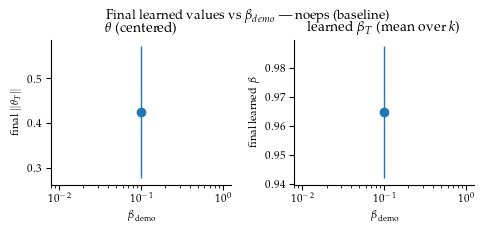

[beta=0.100, lam=0.000, noeps] seeds used = 100 | loaded: /Users/michaelzhou/Desktop/IRLEED-main/results/gridworld_simple/irleed/env_1/demo_beta_0.100/noeps/baseline.p


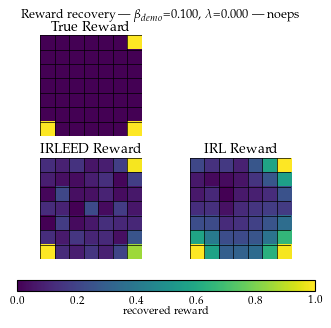

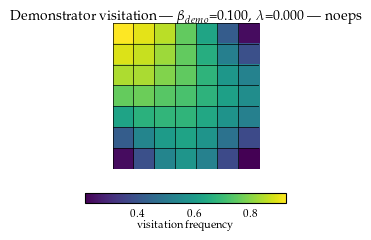

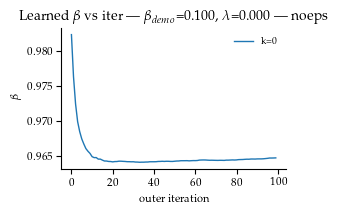

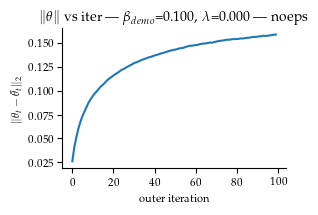

In [24]:
# MAIN LOOP

USE_EPS = False
eps_str = 'eps' if USE_EPS else 'noeps'

betas = np.array([0.1])          # or [0.1, 1, 5, 10]
lams  = np.array([0]) # should be baseline.p

FIG_OUTDIR = os.path.join(ROOT, "figures")
os.makedirs(FIG_OUTDIR, exist_ok=True)

# gridworld for plotting (env_id=1 => setting=1 7x7)
world, true_reward, terminal, initial = H.setup_mdp(setting=1)

# Plot the final learned params vs beta
out_pdf, stats = plot_final_eps_beta_theta_vs_demo_beta(
    LOAD_DIR=LOAD_DIR,
    betas_demo=betas,
    lam=lams[0],        # ignored because eps_str=noeps => baseline.p
    USE_EPS=USE_EPS,
    FIG_OUTDIR=FIG_OUTDIR,
    env_id=1
)

for beta in betas:
    for lam in lams:
        # ----- load -----
        options, data, path = load_cell(LOAD_DIR, beta, lam, eps_str, env_id=1)

        # pick ONE representative seed FOR THIS (beta,lam) CELL
        seed_id, dat = get_first_valid_seed(data)

        # ----- aggregate -----
        returns_mean, theta_pair_mean, feat_mean, eps_final_mean, eps_hist_mean, betas_hist_mean, theta_hist_mean, count, K, T = aggregate_cell(data, max_T=options['max_steps'], ratios=options["ratios"])
        print(f"[beta={beta:.3f}, lam={lam:.3f}, {eps_str}] seeds used = {count} | loaded: {path}")

        # ----- plots -----
        theta0 = theta_pair_mean[0]
        thetaT = theta_pair_mean[1]
        
        # # Plot trajectories 
        # for dat in data:
        #     if dat is None:
        #         continue
        #     if 'mix_traj' not in dat:
        #         continue
        
        #     for comp_id, trajectories in enumerate(dat['mix_traj']):
        #         plot_trajectories(
        #             world,
        #             trajectories,
        #             n=20,
        #             title=f"seed demo trajectories (component {comp_id})",
        #             terminal_states=terminal,  # if you have it
        #         )
        
        plot_reward_triptych(world, true_reward, theta0, thetaT, beta, lam, eps_str, FIG_OUTDIR)
        # plot_visitation(world, normalize(visit_mean), beta, lam, eps_str, FIG_OUTDIR)
        plot_visitation(world, feat_mean, beta, lam, eps_str, FIG_OUTDIR)

        if USE_EPS and (eps_final_mean is not None):
            plot_epsilon_negmag(world, eps_final_mean, beta, lam, eps_str, FIG_OUTDIR)

        if USE_EPS and (eps_hist_mean is not None):
            plot_eps_norm_vs_iter(eps_hist_mean, beta, lam, eps_str, FIG_OUTDIR)
            
            # # or the global version:
            # plot_eps_global_norm_vs_iter(eps_hist_mean, beta, lam, eps_str, FIG_OUTDIR)
        
        if betas_hist_mean is not None:
            plot_beta_vs_iter(betas_hist_mean, beta, lam, eps_str, FIG_OUTDIR)

        if theta_hist_mean is not None:
            plot_theta_norm_vs_iter(theta_hist_mean, beta, lam, eps_str, FIG_OUTDIR)

        # ----- single-seed per-demonstrator figure -----
        # only meaningful WITH epsilon and if epsilons are logged
        if USE_EPS and ('epsilons' in dat['log']) and (dat['log']['epsilons'] is not None):
            plot_single_seed_demonstrator_rewards(
                world=world,
                true_reward=true_reward,
                dat=dat,
                beta=beta,
                lam=lam,
                seed_id=seed_id,
                eps_str=eps_str,
                save_dir=FIG_OUTDIR
            )